In [110]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df= pd.read_csv("/content/Walmart.csv")
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [111]:
df.info()
df.isnull().sum()
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


np.int64(0)

check for correlation

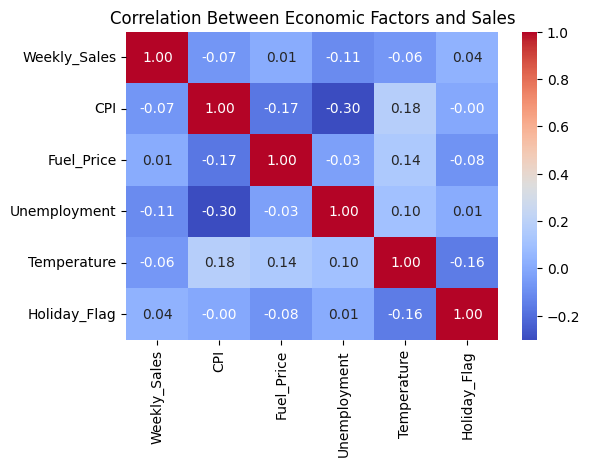

In [112]:
import seaborn as sns

corr = df[['Weekly_Sales','CPI','Fuel_Price','Unemployment','Temperature','Holiday_Flag']].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Between Economic Factors and Sales")
plt.show()


Scatter plot for across all how it affected the sales

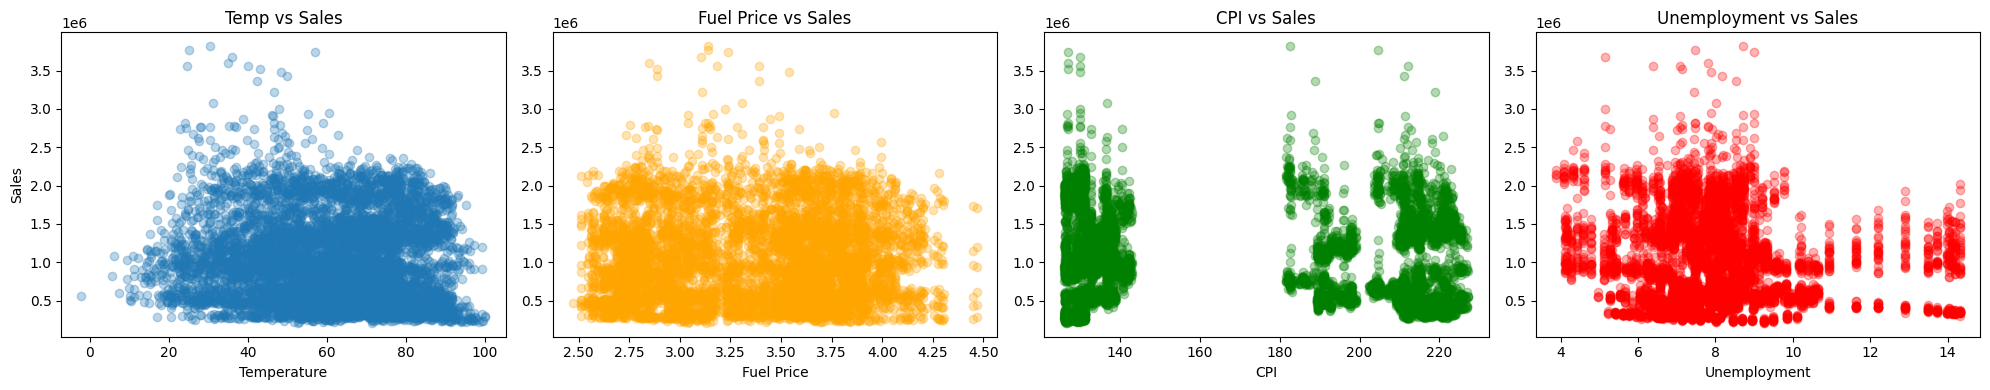

In [113]:
fig, axes = plt.subplots(1, 4, figsize=(20,4))

# Temperature
axes[0].scatter(df['Temperature'], df['Weekly_Sales'], alpha=0.3)
axes[0].set_title("Temp vs Sales")
axes[0].set_xlabel("Temperature")
axes[0].set_ylabel("Sales")

# Fuel Price
axes[1].scatter(df['Fuel_Price'], df['Weekly_Sales'], alpha=0.3, color='orange')
axes[1].set_title("Fuel Price vs Sales")
axes[1].set_xlabel("Fuel Price")

# CPI
axes[2].scatter(df['CPI'], df['Weekly_Sales'], alpha=0.3, color='green')
axes[2].set_title("CPI vs Sales")
axes[2].set_xlabel("CPI")

# Unemployment
axes[3].scatter(df['Unemployment'], df['Weekly_Sales'], alpha=0.3, color='red')
axes[3].set_title("Unemployment vs Sales")
axes[3].set_xlabel("Unemployment")

plt.tight_layout()
plt.show()


 Convert Date Column

In [114]:
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')
df = df.sort_values('Date')
df.head()



,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106
1287,10,2010-02-05,2193048.75,0,54.34,2.962,126.442065,9.765
5148,37,2010-02-05,536006.73,0,45.97,2.572,209.852966,8.554
2288,17,2010-02-05,789036.02,0,23.11,2.666,126.442065,6.548
4147,30,2010-02-05,465108.52,0,39.05,2.572,210.752605,8.324


Select One Store

We start with Store 1.

In [115]:
df['Store'].nunique()

45

In [116]:
store_id = 1
store_df = df[df['Store'] == store_id].copy()

store_df.head()


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106


Plot Weekly Sales Trend


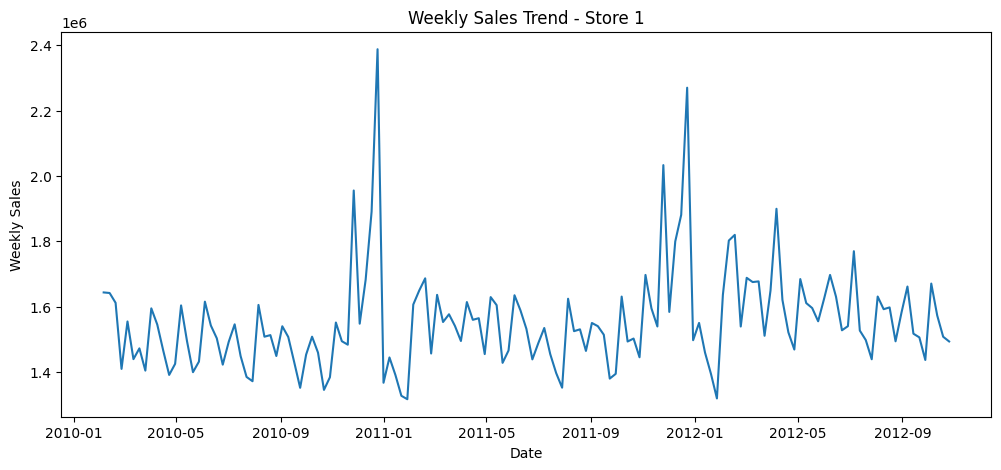

In [117]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(store_df['Date'], store_df['Weekly_Sales'])
plt.title("Weekly Sales Trend - Store 1")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.show()


Time-Based Train/Test Split

We now split data into:

Train → past weeks (to learn pattern)

Test → recent weeks (to evaluate model)

In [118]:
split_date = store_df['Date'].quantile(0.8)

train = store_df[store_df['Date'] <= split_date]
test  = store_df[store_df['Date'] > split_date]

print("Train rows:", len(train))
print("Test rows:", len(test))


Train rows: 114
Test rows: 29


 Prepare Data for Prophet


In [119]:
prophet_train = train[['Date','Weekly_Sales']].copy()
prophet_train.columns = ['ds','y']


 Install Prophet

In [120]:
!pip install prophet



 Train Prophet Model


In [121]:
from prophet import Prophet

model = Prophet()
model.fit(prophet_train)


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [122]:
future = test[['Date']].rename(columns={'Date':'ds'})
forecast = model.predict(future)


 Calculate Error


In [123]:
actual = test['Weekly_Sales'].reset_index(drop=True)
pred   = forecast['yhat'].reset_index(drop=True)

from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(actual, pred)
mape = (abs(actual - pred) / actual).mean() * 100

print(f"MAE: {mae:.2f}  |  MAPE: {mape:.2f}%")




MAE: 60671.93  |  MAPE: 3.87%


#Now we can build SARIMAX model

Create Time Series Index

In [124]:
train_ts = train.set_index('Date')['Weekly_Sales']
test_ts  = test.set_index('Date')['Weekly_Sales']


In [125]:
train_ts.head()

,Weekly_Sales
Date,
2010-02-05,1643690.90
2010-02-12,1641957.44
2010-02-19,1611968.17
2010-02-26,1409727.59
2010-03-05,1554806.68


 Install SARIMA Library

SARIMA is inside statsmodels.

In [126]:
!pip install statsmodels


 Build SARIMA Model

In [127]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model_sarima = SARIMAX(
    train_ts,
    order=(1,1,1),
    seasonal_order=(1,1,1,52)
)

sarima_fit = model_sarima.fit(disp=False)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


 Forecast Test Period

In [128]:
sarima_forecast = sarima_fit.forecast(steps=len(test_ts))
sarima_forecast


,predicted_mean
2012-04-13,1.824194e+06
2012-04-20,1.818098e+06
2012-04-27,1.728363e+06
2012-05-04,1.884136e+06
2012-05-11,1.856531e+06
2012-05-18,1.704162e+06
2012-05-25,1.737598e+06
2012-06-01,1.889540e+06
2012-06-08,1.846576e+06
2012-06-15,1.796954e+06


 Calculate *Error*

In [129]:
from sklearn.metrics import mean_absolute_error

actual = test_ts.reset_index(drop=True)
pred   = sarima_forecast.reset_index(drop=True)

mae_sarima = mean_absolute_error(actual, pred)
mape_sarima = (abs(actual - pred) / actual).mean() * 100

print(f"SARIMA MAE: {mae_sarima:.2f} | SARIMA MAPE: {mape_sarima:.2f}%")


SARIMA MAE: 203230.54 | SARIMA MAPE: 13.05%


# ML prediction

 Create Time Features

In [130]:
ml_df = store_df.copy()
ml_df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106


we do some manual feature enginerring to extract column

In [131]:
ml_df['year'] = ml_df['Date'].dt.year
ml_df['month'] = ml_df['Date'].dt.month
ml_df['week'] = ml_df['Date'].dt.isocalendar().week.astype(int)

In [132]:
ml_df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,year,month,week
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2010,2,5
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,2010,2,6
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,2010,2,7
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,2010,2,8
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,2010,3,9


 Create Lag Feature


In [133]:
ml_df['lag_1'] = ml_df['Weekly_Sales'].shift(1)


 Drop Missing Rows

In [134]:
ml_df.isnull().sum()

,0
Store,0
Date,0
Weekly_Sales,0
Holiday_Flag,0
Temperature,0
Fuel_Price,0
CPI,0
Unemployment,0
year,0
month,0


In [135]:
ml_df = ml_df.dropna()

 Train/Test Split Again

In [136]:
split_date = ml_df['Date'].quantile(0.8)

train_ml = ml_df[ml_df['Date'] <= split_date]
test_ml  = ml_df[ml_df['Date'] > split_date]


In [137]:
features = ['year','month','week','lag_1']

X_train = train_ml[features]
y_train = train_ml['Weekly_Sales']

X_test = test_ml[features]
y_test = test_ml['Weekly_Sales']


In [138]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train, y_train)


RandomForestRegressor(n_estimators=300, random_state=42)

 Predict Using Random Forest

In [139]:
pred_rf = rf.predict(X_test)


 Evaluate Random Forest

In [140]:
from sklearn.metrics import mean_absolute_error

mae_rf = mean_absolute_error(y_test, pred_rf)
mape_rf = (abs(y_test - pred_rf) / y_test).mean() * 100

print(f"Random Forest MAE: {mae_rf:.2f} | Random Forest MAPE: {mape_rf:.2f}%")


Random Forest MAE: 76921.35 | Random Forest MAPE: 4.91%


 Train XGBoost

In [141]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5
)

xgb.fit(X_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

 Predict Using *XGBoost*

In [142]:
pred_xgb = xgb.predict(X_test)

 Evaluate XGBoost

In [143]:

mae_xgb = mean_absolute_error(y_test, pred_xgb)
mape_xgb = (abs(y_test - pred_xgb) / y_test).mean() * 100

print(f"XGBoost MAE: {mae_xgb:.2f} | XGBoost MAPE: {mape_xgb:.2f}%")


XGBoost MAE: 58717.93 | XGBoost MAPE: 3.75%


Create a comparison table

In [144]:
import pandas as pd

results = pd.DataFrame({
    'Model': ['Prophet','SARIMA','Random Forest','XGBoost'],
    'MAPE': [3.87, 13.05, 4.91, 3.75]
})

results


,Model,MAPE
0,Prophet,3.87
1,SARIMA,13.05
2,Random Forest,4.91
3,XGBoost,3.75


Plot comparison chart

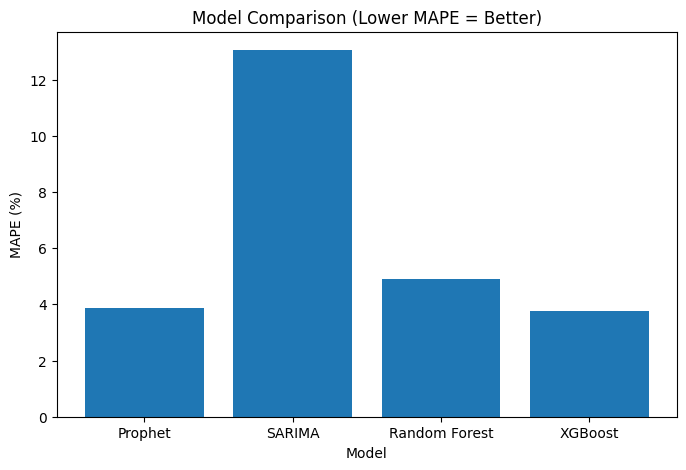

In [145]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(results['Model'], results['MAPE'])
plt.title("Model Comparison (Lower MAPE = Better)")
plt.ylabel("MAPE (%)")
plt.xlabel("Model")
plt.show()


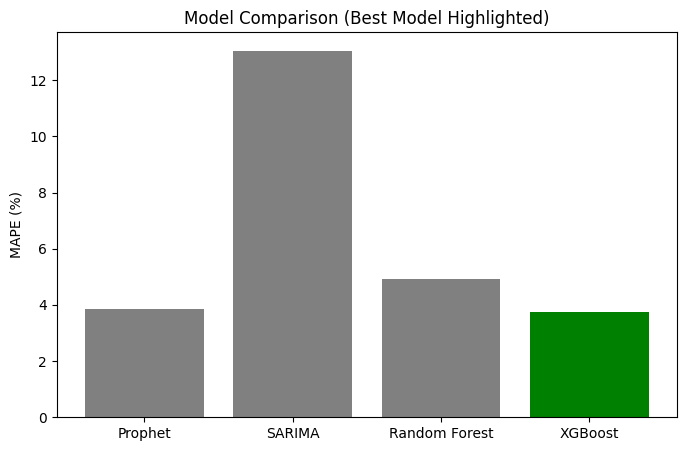

In [146]:
colors = ['grey','grey','grey','green']

plt.figure(figsize=(8,5))
plt.bar(results['Model'], results['MAPE'], color=colors)
plt.title("Model Comparison (Best Model Highlighted)")
plt.ylabel("MAPE (%)")
plt.show()


“We compared multiple forecasting models visually using MAPE. XGBoost showed the lowest error, so we selected it for demand forecasting and inventory planning.”

Loop through each store and Train XGBoost on that store’s history and Forecast future demand and

 Save results

At the end we’ll know:
✔ Which stores will sell more
✔ Which stores need more inventory

Get list of stores

In [147]:
stores = df['Store'].unique()
stores


array([ 1, 10, 37, 17, 30, 25, 22, 23, 24, 19, 21, 26, 39,  8, 32, 15, 34,
       13, 38,  9,  2, 45, 20, 27, 41,  4, 31, 16, 11, 36, 42,  5, 43, 35,
       28,  6, 33, 44, 18,  3, 12, 29, 40,  7, 14])

In [148]:
#Create an empty list and loop through stores

store_predictions = []

for store in stores:

    store_df = df[df['Store']==store].copy()

    # create time features
    store_df['year'] = store_df['Date'].dt.year
    store_df['month'] = store_df['Date'].dt.month
    store_df['week'] = store_df['Date'].dt.isocalendar().week.astype(int)

    # lag feature
    store_df['lag_1'] = store_df['Weekly_Sales'].shift(1)
    store_df = store_df.dropna()

    # train/test split
    split_date = store_df['Date'].quantile(0.8)
    train_store = store_df[store_df['Date'] <= split_date]
    test_store  = store_df[store_df['Date'] > split_date]

    features = ['year','month','week','lag_1']

    X_train = train_store[features]
    y_train = train_store['Weekly_Sales']
    X_test  = test_store[features]

    # train XGBoost
    model = XGBRegressor(n_estimators=300, learning_rate=0.05)
    model.fit(X_train, y_train)

    # predict future demand
    preds = model.predict(X_test)

    # store total future demand
    total_future = preds.sum()

    # Store-wise demand variability
    store_std = store_df['Weekly_Sales'].std()

    #Avg weekly demand
    avg_weekly = total_future / len(preds)

    #Safety stock per store
    service_level = 1.65   # 95% service level
    lead_time_weeks = 2    # example lead time

    #Using globally defined lead_time_weeks and service_level from earlier cells
    safety_stock = service_level * store_std * (lead_time_weeks**0.5)

    #Reorder point
    reorder_point = avg_weekly * lead_time_weeks + safety_stock

    #Save results
    store_predictions.append([store, total_future, avg_weekly, store_std, safety_stock, reorder_point])

Convert results to table

In [149]:
results_df = pd.DataFrame(store_predictions, columns=[ 'Store', 'Future_Demand', 'Avg_Weekly_Demand', 'Demand_STD', 'Safety_Stock', 'Reorder_Point'])
results_df = results_df.sort_values('Future_Demand', ascending=False)
results_df.head()

,Store,Future_Demand,Avg_Weekly_Demand,Demand_STD,Safety_Stock,Reorder_Point
25,4,68746760.0,2370578.00,267121.898874,623316.230121,5364472.0
22,20,65398080.0,2255106.25,275762.269889,643478.124413,5153690.5
44,14,63435824.0,2187442.25,314600.311124,734104.844084,5108989.5
17,13,61911668.0,2134885.00,266429.088248,621699.589518,4891469.5
20,2,54697336.0,1886115.00,237856.067039,555025.805233,4327256.0


In [150]:
#Convert only if columns exist
cols = ['Future_Demand','Avg_Weekly_Demand','Safety_Stock','Reorder_Point']

for col in cols:
    if col in results_df.columns:
        results_df[col] = pd.to_numeric(results_df[col], errors='coerce')
        results_df[col] = results_df[col] / 1_000_000

#Round up the value
for col in cols:
    if col in results_df.columns:
        results_df[col] = results_df[col].round(2)

#Rename columns
rename_map = {
    'Future_Demand':'Future_Demand (M)',
    'Avg_Weekly_Demand':'Avg_Weekly_Demand (M)',
    'Safety_Stock':'Safety_Stock (M)',
    'Reorder_Point':'Reorder_Point (M)'
}

results_df = results_df.rename(columns=rename_map)

#final table
results_df.head()


,Store,Future_Demand (M),Avg_Weekly_Demand (M),Demand_STD,Safety_Stock (M),Reorder_Point (M)
25,4,68.750000,2.37,267121.898874,0.62,5.36
22,20,65.400002,2.26,275762.269889,0.64,5.15
44,14,63.439999,2.19,314600.311124,0.73,5.11
17,13,61.910000,2.13,266429.088248,0.62,4.89
20,2,54.700001,1.89,237856.067039,0.56,4.33


Visualize Top Demand Stores

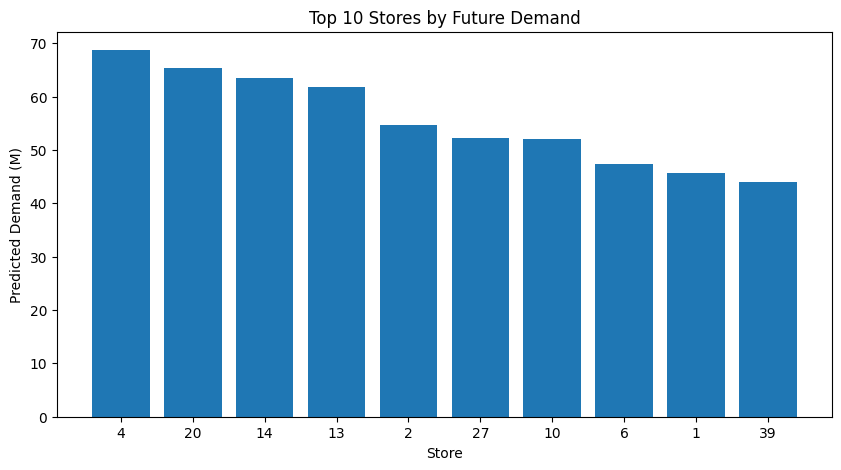

In [151]:
top10 = results_df.head(10)

plt.figure(figsize=(10,5))
plt.bar(top10['Store'].astype(str), top10['Future_Demand (M)'])
plt.title("Top 10 Stores by Future Demand")
plt.xlabel("Store")
plt.ylabel("Predicted Demand (M)")
plt.show()

Stores Needing Highest Safety Stock

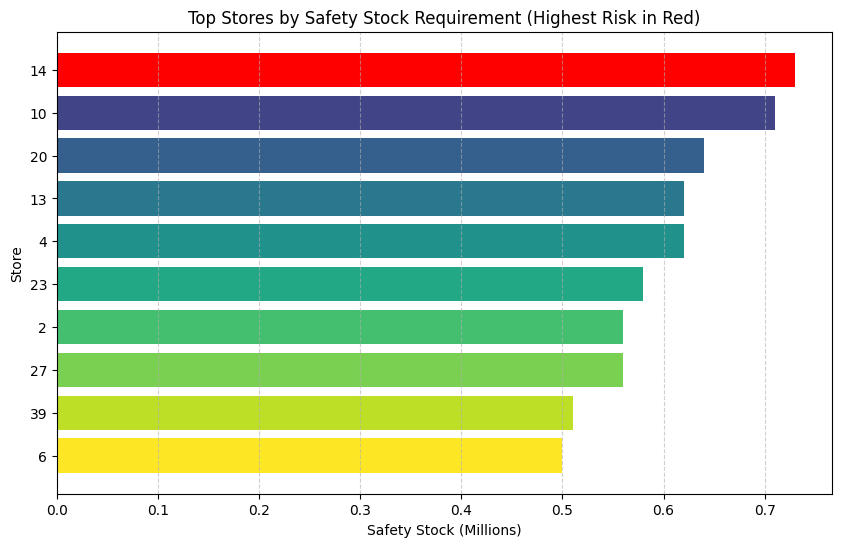

In [152]:
import matplotlib.pyplot as plt
import numpy as np

top10_ss = results_df.sort_values('Safety_Stock (M)', ascending=False).head(10)

stores = top10_ss['Store'].astype(str)
values = top10_ss['Safety_Stock (M)']

# create colors: first one red, rest gradient
colors = ['red'] + list(plt.cm.viridis(np.linspace(0.2,1,len(stores)-1)))

plt.figure(figsize=(10,6))

plt.barh(stores, values, color=colors)

plt.title("Top Stores by Safety Stock Requirement (Highest Risk in Red)")
plt.xlabel("Safety Stock (Millions)")
plt.ylabel("Store")

plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.show()



Compute ACTUAL store demand from test period

In [153]:
# get same test period used in modeling
split_date = df['Date'].quantile(0.8)
actual_test = df[df['Date'] > split_date]

# sum real sales per store
actual_sales = (
    actual_test.groupby('Store')['Weekly_Sales']
    .sum()
    .reset_index()
    .rename(columns={'Weekly_Sales':'Actual_Demand'})
)

# convert to millions for readability
actual_sales['Actual_Demand'] = actual_sales['Actual_Demand'] / 1_000_000


In [154]:
#predicted table
predicted = results_df.copy()
predicted = predicted.rename(columns={ 'Future_Demand (M)':'Predicted_Demand'})

In [155]:
#Merge actual and predicted
compare_df = predicted[['Store','Predicted_Demand']].merge( actual_sales, on='Store', how='left')

In [156]:
#Ranking columns
compare_df['Predicted_Rank'] = compare_df['Predicted_Demand'].rank(ascending=False)
compare_df['Actual_Rank'] = compare_df['Actual_Demand'].rank(ascending=False)


In [157]:
#Sort by predicted rank
compare_df = compare_df.sort_values('Predicted_Rank')

compare_df.head(10)


,Store,Predicted_Demand,Actual_Demand,Predicted_Rank,Actual_Rank
0,4,68.750000,60.265371,1.0,1.0
1,20,65.400002,58.245446,2.0,2.0
2,14,63.439999,48.675974,3.0,6.0
3,13,61.910000,57.195412,4.0,3.0
4,2,54.700001,52.903570,5.0,4.0
5,27,52.230000,48.077626,6.0,7.0
6,10,52.080002,49.601601,7.0,5.0
7,6,47.459999,43.390581,8.0,10.0
8,1,45.759998,43.957587,9.0,8.0
9,39,44.099998,43.799478,10.0,9.0


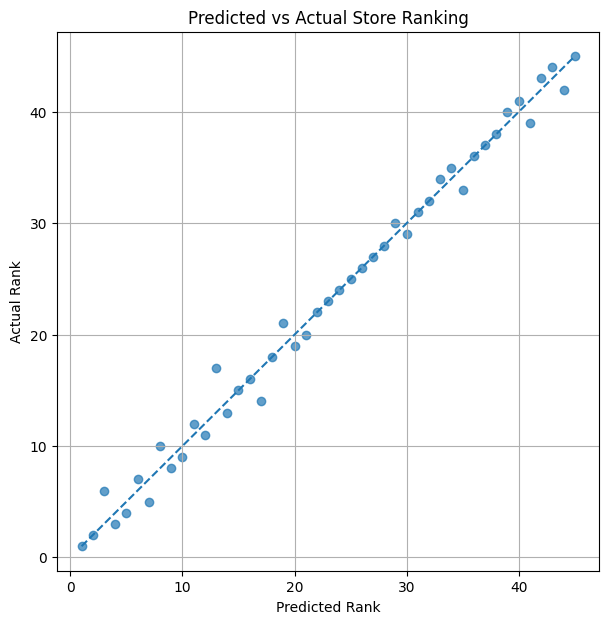

In [158]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))

plt.scatter(compare_df['Predicted_Rank'],
            compare_df['Actual_Rank'],
            alpha=0.7)

# perfect prediction reference line
max_rank = max(compare_df['Predicted_Rank'].max(),
               compare_df['Actual_Rank'].max())

plt.plot([1, max_rank], [1, max_rank], linestyle='--')

plt.xlabel("Predicted Rank")
plt.ylabel("Actual Rank")
plt.title("Predicted vs Actual Store Ranking")

plt.grid(True)
plt.show()
